# Day 10 — Benchmarks and their limits

**What MMLU, HumanEval, and friends actually measure — and the five ways a headline benchmark
number misleads you.** We implement mini versions of both benchmark styles (multiple-choice
and code-execution), then break them on purpose.

## Agenda (60 min)

| # | Segment | Time |
| - | ------- | ---- |
| 0 | Why benchmarks exist, and the two styles | 4 min |
| 1 | Mini-MMLU: multiple choice + the chance floor | 11 min |
| 2 | Mini-HumanEval: pass@k with real execution | 13 min |
| 3 | Contamination: memorising the test set | 10 min |
| 4 | Aggregation hides weakness; prompt sensitivity | 12 min |
| 5 | Goodhart: what happens when a benchmark becomes a target | 5 min |
| 6 | Exercises + quiz | 5 min |

Kernel: **Python (ai-upskill)**.

In [1]:
import numpy as np, random, re, io, contextlib, textwrap
import matplotlib.pyplot as plt
rng = np.random.default_rng(0); random.seed(0)
print("ready")

ready


## 0 — Why benchmarks, and the two styles (4 min)

A benchmark is a fixed test set + a scoring rule, so two models can be compared on the same
yardstick. Almost every LLM benchmark is one of two shapes:

- **Multiple-choice / exact-match** (MMLU, ARC, GSM8K, TruthfulQA-MC): the model picks an
  option or emits a short string; score = accuracy. Cheap, objective, easy to game.
- **Execution / verifier-based** (HumanEval, MBPP, SWE-bench): the model produces code; score
  = does it pass hidden tests. Closer to real utility, more expensive, still narrow.

Everything else (chat quality, helpfulness) needs human or LLM judges — Week 9.

## 1 — Mini-MMLU (11 min)

MMLU = 57 subjects, 4-option multiple choice, score = % correct. Two things to internalise:
the **chance floor is 25%**, and a model that knows *nothing* but has a format bias can beat
chance.

In [2]:
# A tiny 4-subject MMLU. (answer index is 0-3)
MMLU = {
 "math": [("2+2*2 = ?", ["6","8","4","2"], 0), ("sqrt(144) = ?", ["11","12","13","14"], 1),
          ("prime? 51", ["yes","no","maybe","n/a"], 1)],
 "history": [("year WW2 ended", ["1943","1944","1945","1946"], 2),
             ("first US president", ["Adams","Jefferson","Washington","Lincoln"], 2),
             ("Magna Carta year", ["1066","1215","1492","1776"], 1)],
 "biology": [("powerhouse of the cell", ["nucleus","ribosome","mitochondria","golgi"], 2),
             ("DNA base pairs with A", ["G","C","T","U"], 2),
             ("humans chromosomes", ["23","44","46","48"], 2)],
 "law": [("beyond reasonable doubt is used in", ["civil","criminal","both","neither"], 1),
         ("US amendments count", ["10","23","27","33"], 2),
         ("stare decisis means", ["new law","stand by decided","jury trial","appeal"], 1)],
}

def run_mmlu(model_fn):
    per = {}
    for subj, qs in MMLU.items():
        correct = sum(model_fn(subj, q, opts) == ans for q, opts, ans in qs)
        per[subj] = correct / len(qs)
    overall = np.mean(list(per.values()))
    return overall, per

# baselines
def always_A(subj, q, opts): return 0
def random_guess(subj, q, opts): return random.randrange(len(opts))

print("always-A  :", run_mmlu(always_A))
print("random    :", np.mean([run_mmlu(random_guess)[0] for _ in range(200)]).round(3))

always-A  : (np.float64(0.08333333333333333), {'math': 0.3333333333333333, 'history': 0.0, 'biology': 0.0, 'law': 0.0})
random    : 0.236


In [3]:
# A "knowledgeable" model: knows a topic with probability p_subj, else guesses.
# When it knows, it identifies the correct ANSWER TEXT and returns its index in whatever
# option order it was given -> robust to option shuffling (real understanding).
KNOWLEDGE = {"math": 0.9, "history": 0.5, "biology": 0.8, "law": 0.2}
def correct_text(subj, q):
    for qq, oo, aa in MMLU[subj]:
        if qq == q: return oo[aa]
    return None
def smart_model(subj, q, opts, know=KNOWLEDGE):
    if random.random() < know[subj]:
        t = correct_text(subj, q)
        if t in opts: return opts.index(t)
    return random.randrange(len(opts))

runs = [run_mmlu(smart_model) for _ in range(300)]
overall = np.mean([r[0] for r in runs])
per = {s: np.mean([r[1][s] for r in runs]) for s in MMLU}
print(f"smart model overall MMLU: {overall:.2f}")
print("per-subject:", {k: round(v,2) for k,v in per.items()})
print(f"\n-> the single number {overall:.2f} hides that it's near-expert at math/biology and"
      f" barely above the 0.25 floor at law.")

smart model overall MMLU: 0.70
per-subject: {'math': np.float64(0.93), 'history': np.float64(0.62), 'biology': np.float64(0.83), 'law': np.float64(0.4)}

-> the single number 0.70 hides that it's near-expert at math/biology and barely above the 0.25 floor at law.


**Limit #1 — the chance floor.** On 4-way MC, 25% is free. A jump from 25→50 is not "half as
good as perfect"; it's "went from nothing to something". Always subtract the floor mentally:
`(score - 0.25) / 0.75`.

**Limit #2 — aggregation.** MMLU's headline is a mean over 57 subjects. A model tuned to be
great at STEM and weak at humanities can match a balanced model's average while being useless
for your humanities use case.

## 2 — Mini-HumanEval (13 min)

HumanEval = 164 Python problems, each with a function signature, docstring, and hidden unit
tests. Score = **pass@k**: probability that at least one of `k` sampled completions passes all
tests. We build a 4-problem version and actually execute the code.

In [4]:
PROBLEMS = [
 dict(name="add", sig="def add(a, b):", doc="return the sum of a and b",
      tests=["assert add(2,3)==5", "assert add(-1,1)==0"]),
 dict(name="is_even", sig="def is_even(n):", doc="return True if n is even",
      tests=["assert is_even(4)", "assert not is_even(7)"]),
 dict(name="reverse", sig="def reverse(s):", doc="return the string reversed",
      tests=["assert reverse('abc')=='cba'", "assert reverse('')==''"]),
 dict(name="fib", sig="def fib(n):", doc="return the nth Fibonacci number, fib(0)=0, fib(1)=1",
      tests=["assert fib(0)==0", "assert fib(1)==1", "assert fib(10)==55"]),
]

def check(problem, completion):
    src = problem["sig"] + "\n" + textwrap.indent(completion, "    ") \
        if not completion.lstrip().startswith(("def ","    ")) else completion
    env = {}
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            exec(src, env)
            for t in problem["tests"]:
                exec(t, env)
        return True
    except Exception:
        return False

# a "model" that samples one of several candidate bodies, some correct, some buggy
CANDIDATES = {
 "add": ["    return a + b", "    return a - b", "    return a + b + 1"],
 "is_even": ["    return n % 2 == 0", "    return n % 2 == 1", "    return n / 2 == 0"],
 "reverse": ["    return s[::-1]", "    return ''.join(reversed(s))", "    return s"],
 "fib": ["    return n if n<2 else fib(n-1)+fib(n-2)",
         "    a,b=0,1\n    for _ in range(n): a,b=b,a+b\n    return a",
         "    return n*n", "    return n"],
}
def code_model(problem, skill=0.6):
    # with prob skill pick a correct-ish candidate, else a random (often buggy) one
    cands = CANDIDATES[problem["name"]]
    good = [c for c in cands if check(problem, c)]
    if good and random.random() < skill:
        return random.choice(good)
    return random.choice(cands)

def pass_at_k(problem, k, skill, trials=400):
    hits = 0
    for _ in range(trials):
        ok = any(check(problem, code_model(problem, skill)) for _ in range(k))
        hits += ok
    return hits / trials

for k in [1, 3, 10]:
    scores = [pass_at_k(p, k, skill=0.5) for p in PROBLEMS]
    print(f"pass@{k:<2}: per-problem {[round(s,2) for s in scores]}  mean {np.mean(scores):.2f}")

pass@1 : per-problem [0.66, 0.65, 0.84, 0.71]  mean 0.72


pass@3 : per-problem [0.97, 0.96, 1.0, 0.99]  mean 0.98


pass@10: per-problem [1.0, 1.0, 1.0, 1.0]  mean 1.00


**Limit #3 — pass@k is not pass@1.** pass@10 lets the model take 10 shots and counts a win if
*any* pass. It's a real capability measure (useful with a verifier / test suite in the loop)
but a paper reporting pass@100 is describing a very different product than one shipping a
single completion. Always check which `k` a headline uses.

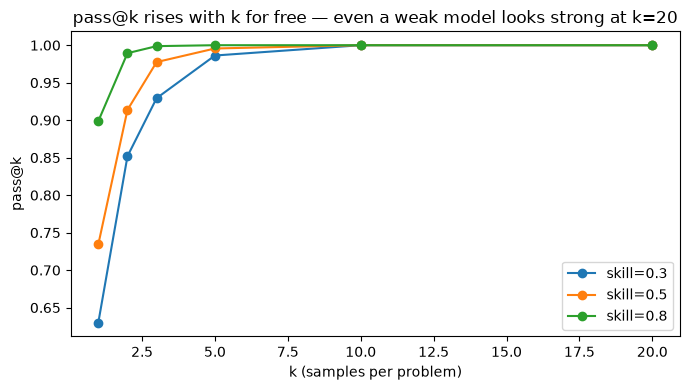

In [5]:
plt.figure(figsize=(7,4))
for skill in [0.3, 0.5, 0.8]:
    ks = [1,2,3,5,10,20]
    plt.plot(ks, [np.mean([pass_at_k(p,k,skill) for p in PROBLEMS]) for k in ks],
             marker="o", label=f"skill={skill}")
plt.xlabel("k (samples per problem)"); plt.ylabel("pass@k"); plt.legend()
plt.title("pass@k rises with k for free — even a weak model looks strong at k=20")
plt.tight_layout(); plt.show()

## 3 — Contamination (10 min)

If the benchmark's questions (or answers) were in the training data, the score measures
memory, not capability. This is the single biggest threat to public-benchmark validity today.

In [6]:
# A contaminated model: it has memorised the MMLU answer key verbatim.
LEAKED_KEY = {(subj, q): ans for subj, qs in MMLU.items() for q, opts, ans in qs}
def contaminated(subj, q, opts):
    return LEAKED_KEY.get((subj, q), random.randrange(len(opts)))

print("contaminated model MMLU:", run_mmlu(contaminated))    # -> 1.00, "perfect"

# detection idea 1: perturb the questions (paraphrase / reorder options). Real skill survives;
# memorisation collapses.
def perturb_options(subj, q, opts, ans):
    perm = list(range(len(opts))); random.shuffle(perm)
    new_opts = [opts[i] for i in perm]
    new_ans = perm.index(ans)
    return new_opts, new_ans

def run_mmlu_perturbed(model_fn):
    per = {}
    for subj, qs in MMLU.items():
        c = 0
        for q, opts, ans in qs:
            new_opts, new_ans = perturb_options(subj, q, opts, ans)
            # model still keyed on original q text, but options are shuffled
            pred = model_fn(subj, q, new_opts)
            c += (pred == new_ans)
        per[subj] = c/len(qs)
    return np.mean(list(per.values())), per

print("contaminated, options shuffled:", run_mmlu_perturbed(lambda s,q,o: LEAKED_KEY.get((s,q),0))[0],
      " <- memorised INDEX, not the answer -> collapses")
print("genuinely-knows model, shuffled:", round(np.mean([run_mmlu_perturbed(smart_model)[0]
                                                          for _ in range(200)]),2), " <- survives")

contaminated model MMLU: (np.float64(1.0), {'math': 1.0, 'history': 1.0, 'biology': 1.0, 'law': 1.0})
contaminated, options shuffled: 0.08333333333333333  <- memorised INDEX, not the answer -> collapses
genuinely-knows model, shuffled: 0.7  <- survives


**Limit #4 — contamination.** Signs to look for: implausibly high scores on old benchmarks,
big drops on freshly-written or perturbed variants, scores that don't track downstream
performance. Mitigations: private/held-out test sets, canary strings, time-split benchmarks
(only test on data created after the training cutoff), and reporting on paraphrased variants.

## 4 — Aggregation & prompt sensitivity (12 min)

In [7]:
# Same model, same questions, different PROMPT FORMAT -> different score.
# We simulate: the model's accuracy depends on how well the format matches its training.
FORMAT_BONUS = {"letters": 0.0, "numbers": -0.15, "verbose": -0.05, "json": -0.20}
def formatted_model(subj, q, opts, fmt="letters"):
    base = KNOWLEDGE[subj] + FORMAT_BONUS[fmt]
    if random.random() < max(0, base):
        for qq,oo,aa in MMLU[subj]:
            if qq==q: return aa
    return random.randrange(len(opts))

for fmt in FORMAT_BONUS:
    s = np.mean([run_mmlu(lambda su,q,o: formatted_model(su,q,o,fmt))[0] for _ in range(200)])
    print(f"prompt format = {fmt:8s} -> MMLU {s:.2f}")
print("\n-> up to ~15 points swing from formatting alone. Leaderboard gaps smaller than this")
print("   are noise unless every model used an identical harness.")

prompt format = letters  -> MMLU 0.70
prompt format = numbers  -> MMLU 0.59
prompt format = verbose  -> MMLU 0.65
prompt format = json     -> MMLU 0.56

-> up to ~15 points swing from formatting alone. Leaderboard gaps smaller than this
   are noise unless every model used an identical harness.


In [8]:
# Aggregation: two models, same overall, opposite profiles.
model_stem = {"math": 0.95, "history": 0.35, "biology": 0.95, "law": 0.30}
model_bal  = {"math": 0.65, "history": 0.65, "biology": 0.65, "law": 0.60}
def mk(know): return lambda s,q,o: (next((aa for qq,oo,aa in MMLU[s] if qq==q), 0)
                                    if random.random()<know[s] else random.randrange(len(o)))
a = np.mean([run_mmlu(mk(model_stem))[0] for _ in range(300)])
b = np.mean([run_mmlu(mk(model_bal))[0] for _ in range(300)])
print(f"STEM-heavy model overall {a:.2f}   balanced model overall {b:.2f}")
print("nearly identical headline. If your app is legal Q&A, they are NOT interchangeable.")

STEM-heavy model overall 0.72   balanced model overall 0.72
nearly identical headline. If your app is legal Q&A, they are NOT interchangeable.


**Limit #5 — the number isn't your task.** A benchmark is a proxy. The only evaluation that
matters is one built from *your* inputs and *your* success criteria (Day 06, and Week 9).
Public benchmarks are for narrowing the shortlist, not for the final call.

## 5 — Goodhart's law (5 min)

> "When a measure becomes a target, it ceases to be a good measure."

Once a benchmark is influential, the ecosystem optimises for it: training on similar data,
tuning prompt formats, selecting checkpoints by benchmark score. The benchmark saturates
(everyone scores ~90) and stops discriminating, while real-world gaps persist.

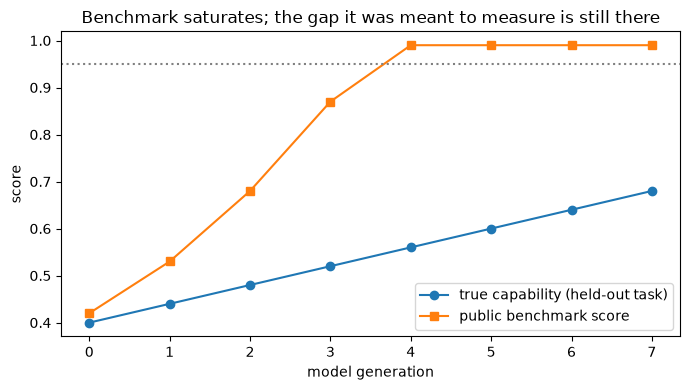

this is why the field keeps retiring benchmarks (MMLU -> MMLU-Pro -> GPQA -> ...)


In [9]:
# simulate: each "generation" of models trains partly on benchmark-like data
gens = range(0, 8)
true_capability = [0.40 + 0.04*g for g in gens]                    # slow real progress
benchmark_score = [min(0.99, 0.42 + 0.09*g + 0.02*g*g) for g in gens]  # fast, then saturates
plt.figure(figsize=(7,4))
plt.plot(list(gens), true_capability, marker="o", label="true capability (held-out task)")
plt.plot(list(gens), benchmark_score, marker="s", label="public benchmark score")
plt.axhline(0.95, ls=":", color="gray"); plt.xlabel("model generation"); plt.ylabel("score")
plt.legend(); plt.title("Benchmark saturates; the gap it was meant to measure is still there")
plt.tight_layout(); plt.show()
print("this is why the field keeps retiring benchmarks (MMLU -> MMLU-Pro -> GPQA -> ...)")

### The honest use of benchmarks

| Do | Don't |
| -- | ----- |
| Use them to shortlist 2–3 candidates | Pick a model on a 1–2 point leaderboard gap |
| Read *per-category* breakdowns | Trust the single headline mean |
| Check which `k` / prompt / harness was used | Compare scores from different harnesses |
| Prefer fresh / private / time-split sets | Trust high scores on 3-year-old benchmarks |
| Confirm with your own eval (Week 9) | Ship based on public benchmarks alone |

## 6 — Exercises

1. **Chance-floor normalise.** Write `normalize(score, n_options)` = `(s - 1/n)/(1 - 1/n)`.
   Apply it to the smart model's per-subject MMLU. Which subject is genuinely near-zero skill?
2. **pass@1 from pass@k.** For a problem with true per-sample success `p`, pass@k = `1-(1-p)^k`.
   Given an observed pass@10 = 0.80, solve for `p` and hence pass@1. Verify against
   `pass_at_k`.
3. **Contamination stress test.** Add a paraphrase step to `run_mmlu` (swap "year WW2 ended" →
   "in which year did World War II end"). Show the contaminated model drops and `smart_model`
   (keyed on exact text — also drops!). Fix `smart_model` to match on a normalized key and
   show it survives while `contaminated` still fails on shuffled options.
4. **Harness effect.** Sweep `FORMAT_BONUS` and report the max–min MMLU spread. Compare to a
   typical leaderboard gap between the #1 and #5 model (~2–4 points). Conclusion?
5. **Build a time-split.** Split `MMLU` questions into "pre-2020 facts" and "post-2020 facts"
   (invent 3 of each). Argue why testing only on post-cutoff data bounds contamination.
6. **Design a benchmark for your task.** Pick a real task. Write: the test-set source, the
   scoring rule, the chance floor, and one way a model could game it without being better.

> **Attempt every exercise and the quiz first.** The worked solutions and the answer key live in [`solutions/solutions.ipynb`](solutions/solutions.ipynb) — open it only to check your work, not to start.

## Self-check quiz


1. A model scores 45% on a 4-way multiple-choice benchmark. What's the floor-normalised score,
   and why report it?
2. What does pass@10 measure, and why can't you compare it to another model's pass@1?
3. Give two signs that a benchmark result is contaminated.
4. Two models both score 71% on MMLU. Why might one be far better for your use case?
5. Why can the same model, same questions, produce a 15-point score swing?
6. State Goodhart's law and give a concrete LLM example.
7. What is the correct role of public benchmarks in choosing a production model?

## Where this goes next

- **Day 11 — Model tradeoffs:** benchmarks tell you *can* a model do the task; Day 11 is the
  *should you pay for it* question — cost, latency, and accuracy across a model lineup, with a
  runnable tradeoff calculator.